In [1]:
import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

import tensorflow as tf
from tensorflow.keras import Model, regularizers
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    Dropout,
    Bidirectional,
    LSTM,
    GRU,
    MultiHeadAttention,
    Add,
    LayerNormalization,
    GlobalAveragePooling1D,
    Dense,
    Concatenate
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.cm as cm

warnings.filterwarnings("ignore")
tf.keras.backend.clear_session()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input/mitbih-ecg"):
    print("Folder:", root)
    for file in files:
        print("   ", file)

In [6]:
# Change these paths according to your upload location.
# Kaggle examples:
# DATA_DIR = "/kaggle/input/heartbeat"
# DATA_DIR = "/kaggle/input/mitbih-dataset"
DATA_DIR = "/kaggle/input/datasets/thujainanajumuddin/mitbih-ecg"

TRAIN_FILE_CANDIDATES = [
   "mitbih_train.csv"
]

TEST_FILE_CANDIDATES = [
    "mitbih_test.csv"
]

EPOCHS = 25
BATCH_SIZE = 64
VALIDATION_SIZE = 0.20
# SHOULD BE CHANGED TO 1e-5
LEARNING_RATE = 1e-3
# For the common Kaggle MIT-BIH Arrhythmia CSV dataset:
# FOR CONSIDERING ALL CLASS SAMPLES
# 0 = N, 1 = S, 2 = V, 3 = F, 4 = Q
# CLASS_NAMES = ["N", "S", "V", "F", "Q"]
# NUM_CLASSES = len(CLASS_NAMES)


CLASS_NAMES = ["N", "S", "V", "F"]
NUM_CLASSES = len(CLASS_NAMES)
KEEP_CLASSES = list(range(NUM_CLASSES))

In [7]:
def find_file(data_dir, candidate_names):
    all_csv_files = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)
    lower_map = {os.path.basename(path).lower(): path for path in all_csv_files}

    for name in candidate_names:
        if name.lower() in lower_map:
            return lower_map[name.lower()]

    raise FileNotFoundError(
        f"Could not find one of {candidate_names} under {data_dir}. "
        f"Available CSV files: {[os.path.basename(p) for p in all_csv_files]}"
    )


train_csv_path = find_file(DATA_DIR, TRAIN_FILE_CANDIDATES)
test_csv_path = find_file(DATA_DIR, TEST_FILE_CANDIDATES)

print("Train CSV:", train_csv_path)
print("Test CSV :", test_csv_path)

Train CSV: /kaggle/input/datasets/thujainanajumuddin/mitbih-ecg/mitbih_train.csv
Test CSV : /kaggle/input/datasets/thujainanajumuddin/mitbih-ecg/mitbih_test.csv


In [8]:
# # FOR ALL CLASSES
train_df_full = pd.read_csv(train_csv_path, header=None)
test_df = pd.read_csv(test_csv_path, header=None)

# Keep only 4 classes: N, S, V, F
# Remove class Q, which has label 4
train_df_full = train_df_full[train_df_full.iloc[:, -1].isin([0, 1, 2, 3])].reset_index(drop=True)
test_df = test_df[test_df.iloc[:, -1].isin([0, 1, 2, 3])].reset_index(drop=True)

print("Train shape after removing Q:", train_df_full.shape)
print("Test shape after removing Q :", test_df.shape)

print("Train class counts:")
print(train_df_full.iloc[:, -1].value_counts().sort_index())

print("\nTest class counts:")
print(test_df.iloc[:, -1].value_counts().sort_index())

print("Train shape:", train_df_full.shape)
print("Test shape :", test_df.shape)

display(train_df_full.head())

Train shape after removing Q: (81123, 188)
Test shape after removing Q : (20284, 188)
Train class counts:
187
0.0    72471
1.0     2223
2.0     5788
3.0      641
Name: count, dtype: int64

Test class counts:
187
0.0    18118
1.0      556
2.0     1448
3.0      162
Name: count, dtype: int64
Train shape: (81123, 188)
Test shape : (20284, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
def split_features_labels(df):
    X = df.iloc[:, :-1].values.astype(np.float32)
    y = df.iloc[:, -1].values.astype(np.int64)
    return X, y


X_train_full, y_train_full = split_features_labels(train_df_full)
X_test, y_test = split_features_labels(test_df)

detected_classes = sorted(np.unique(np.concatenate([y_train_full, y_test])).astype(int).tolist())
print("Detected classes:", detected_classes)

if max(detected_classes) >= NUM_CLASSES:
    CLASS_NAMES = [f"Class_{i}" for i in range(max(detected_classes) + 1)]
    NUM_CLASSES = len(CLASS_NAMES)
    print("Updated class names:", CLASS_NAMES)

print("Train class counts:")
print(pd.Series(y_train_full).value_counts().sort_index())

print("\nTest class counts:")
print(pd.Series(y_test).value_counts().sort_index())

Detected classes: [0, 1, 2, 3]
Train class counts:
0    72471
1     2223
2     5788
3      641
Name: count, dtype: int64

Test class counts:
0    18118
1      556
2     1448
3      162
Name: count, dtype: int64


In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=y_train_full
)

print("Training samples  :", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples   :", X_test.shape[0])

Training samples  : 64898
Validation samples: 16225
Testing samples   : 20284


In [11]:
# DATA FORMATTING AND Z SCORE NORMALIZATION
def ensure_2d_signal_array(X):
    if X.ndim == 3 and X.shape[-1] == 1:
        return X.squeeze(-1)
    if X.ndim != 2:
        raise ValueError(f"Expected a 2D ECG array before scaling, but got shape {X.shape}")
    return X

X_train = ensure_2d_signal_array(X_train)
X_val = ensure_2d_signal_array(X_val)
X_test = ensure_2d_signal_array(X_test)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [14]:
# code calculates weights so that minority classes receive
# greater importance during training


classes_present = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes_present,
    y=y_train
)

class_weight = {int(cls): float(weight) for cls, weight in zip(classes_present, weights)}
print("Class weights:", class_weight)
# print("y",y_train)

Class weights: {0: 0.27984373113476035, 1: 9.125140607424072, 2: 3.504211663066955, 3: 31.626705653021443}


In [15]:
class ValidationMCCCallback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data, average="macro"):
        super().__init__()
        self.X_val, self.y_val = validation_data
        self.average = average
        self.best_mcc = -1.0
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        probabilities = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(probabilities, axis=1)

        val_precision = precision_score(self.y_val, y_pred, average=self.average, zero_division=0)
        val_recall = recall_score(self.y_val, y_pred, average=self.average, zero_division=0)
        val_f1 = f1_score(self.y_val, y_pred, average=self.average, zero_division=0)
        val_mcc = matthews_corrcoef(self.y_val, y_pred)

        logs["val_precision_macro"] = val_precision
        logs["val_recall_macro"] = val_recall
        logs["val_f1_macro"] = val_f1
        logs["val_mcc"] = val_mcc

        if val_mcc > self.best_mcc:
            self.best_mcc = val_mcc
            self.best_weights = self.model.get_weights()

        print(
            f" - val_precision_macro: {val_precision:.4f}"
            f" - val_recall_macro: {val_recall:.4f}"
            f" - val_f1_macro: {val_f1:.4f}"
            f" - val_mcc: {val_mcc:.4f}"
        )

    def restore_best_mcc_weights(self):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)

In [16]:
def build_ecg_crnn(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv1D(32, kernel_size=7, padding="same", activation="relu")(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    # x = Dropout(0.10)(x)

    x = Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    # x = Dropout(0.10)(x)


    #x = Conv1D(128, kernel_size=3, padding="same", activation="relu")(x)
    x = Conv1D(
    128,
    kernel_size=3,
    padding="same",
    activation="relu",
    name="last_conv"
    )(x)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.10)(x)

# USE MULTI HEAD ATTENTATION
    

    seq = Bidirectional(LSTM(256, return_sequences=True, dropout=0.10))(x)
    seq = BatchNormalization()(seq)

    seq = Bidirectional(LSTM(128, return_sequences=True, dropout=0.10))(seq)
    seq = BatchNormalization()(seq)
    attention_output = MultiHeadAttention(
        num_heads=4,
        key_dim=32
    )(seq, seq)

    seq = Add()([seq, attention_output])
    seq = LayerNormalization()(seq)
    avg_pool = GlobalAveragePooling1D()(seq)
    last_state = Bidirectional(LSTM(64, return_sequences=False, dropout=0.10))(seq)

    x = Concatenate()([avg_pool, last_state])
    #REGULIRIZATION SHOULD BE CHANGED TO 1e-7
    x = Dense(96, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x)
    x = Dropout(0.10)(x)
    x = Dense(48, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x)
    x = Dropout(0.10)(x)

    outputs = Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)


model = build_ecg_crnn(input_shape=X_train.shape[1:], num_classes=NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1783149132.398756      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783149132.405137      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 187, 32)   │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 187, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 93, 32)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 93, 64)    │     10,304 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 93, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 46, 64)    │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ last_conv (Conv1D)  │ (None, 46, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 46, 128)   │        512 │ last_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 23, 128)   │          0 │ batch_normalizat… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 23, 128)   │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 23, 512)   │    788,480 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 23, 512)   │      2,048 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 23, 256)   │    656,384 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 23, 256)   │      1,024 │ bidirectional_1[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 23, 256)   │    131,712 │ batch_normalizat… │
│ (MultiHeadAttentio… │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 23, 256)   │          0 │ batch_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 23, 256)   │        512 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 1,822,484 (6.95 MB)

 Trainable params: 1,820,500 (6.94 MB)

 Non-trainable params: 1,984 (7.75 KB)

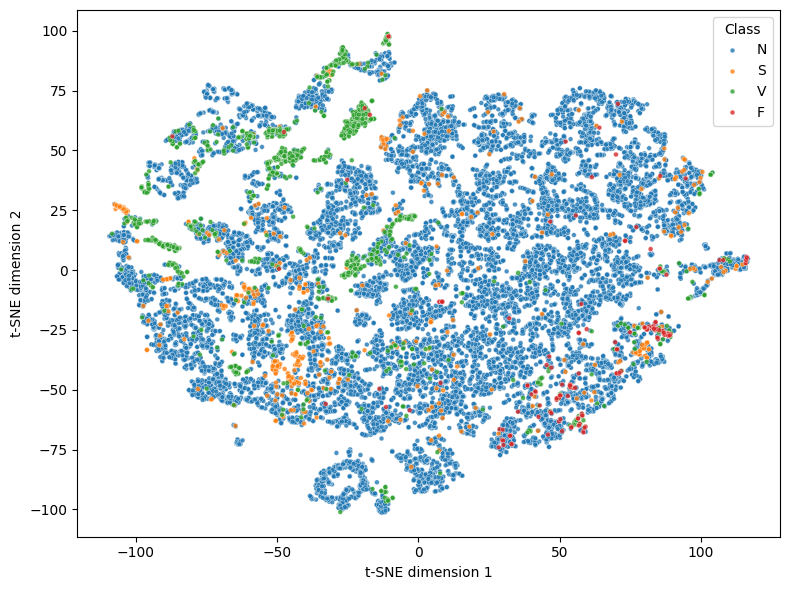

In [17]:

# Take features from the second-last Dense layer
feature_model = Model(
    inputs=model.input,
    outputs=model.layers[-3].output
)

# Use test data for t-SNE
features = feature_model.predict(X_test, verbose=0)

# t-SNE calculation
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=[CLASS_NAMES[i] for i in y_test],
    palette="tab10",
    s=12,
    alpha=0.8
)

# plt.title("t-SNE Visualization of ECG Feature Embeddings")
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [18]:
mcc_callback = ValidationMCCCallback(validation_data=(X_val, y_val), average="macro")

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-8,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=[mcc_callback, reduce_lr],
    verbose=1
)

# Use the best validation-MCC weights for final evaluation.
mcc_callback.restore_best_mcc_weights()
print(f"Best validation MCC: {mcc_callback.best_mcc:.4f}")

Epoch 1/25
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6171 - loss: 0.7868 - val_precision_macro: 0.4779 - val_recall_macro: 0.8348 - val_f1_macro: 0.5515 - val_mcc: 0.5369
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 47s 35ms/step - accuracy: 0.6951 - loss: 0.6598 - val_accuracy: 0.8343 - val_loss: 0.5486 - val_precision_macro: 0.4779 - val_recall_macro: 0.8348 - val_f1_macro: 0.5515 - val_mcc: 0.5369 - learning_rate: 0.0010
Epoch 2/25
1013/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7856 - loss: 0.5085 - val_precision_macro: 0.5451 - val_recall_macro: 0.8540 - val_f1_macro: 0.5986 - val_mcc: 0.5962
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.7779 - loss: 0.5344 - val_accuracy: 0.8727 - val_loss: 0.4809 - val_precision_macro: 0.5451 - val_recall_macro: 0.8540 - val_f1_macro: 0.5986 - val_mcc: 0.5962 - learning_rate: 0.0010
Epoch 3/25
1015/1015 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8404 - loss: 0.4322 - val_precision_macro: 0.4806 - val_recall_macro: 0

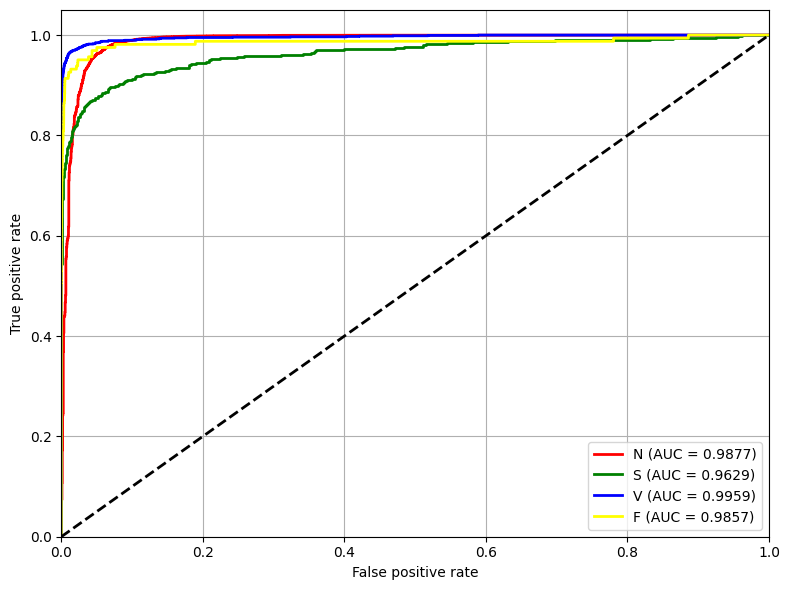

In [21]:
# Number of classes
n_classes = len(CLASS_NAMES)

# True labels (one-hot format)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Predicted probabilities
y_score = model.predict(X_test, verbose=0)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8, 6))

colors = ['red', 'green', 'blue', 'yellow', 'purple']

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.4f})'
    )

# Random classifier line
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
# plt.title("ROC Curve for ECG Classification")
plt.legend(loc="lower right")
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
def evaluate_split(model, X, y_true, split_name):
    loss, acc = model.evaluate(X, y_true, verbose=0)
    probabilities = model.predict(X, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    results = {
        "split": split_name,
        "loss": loss,
        "accuracy": acc,
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "mcc": matthews_corrcoef(y_true, y_pred)
    }
    print(f"{split_name.upper()} RESULTS")
    print(f"{split_name} loss      : {loss:.4f}")
    print(f"{split_name} accuracy  : {acc:.4f}")
    print(f"precision_macro      : {results['precision_macro']:.4f}")
    print(f"recall_macro         : {results['recall_macro']:.4f}")
    print(f"f1_macro             : {results['f1_macro']:.4f}")
    print(f"mcc                  : {results['mcc']:.4f}")

    print("\nClassification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    print("Confusion matrix:")
    print(
        pd.DataFrame(
            cm,
            index=CLASS_NAMES,
            columns=CLASS_NAMES
        )
    )

    return results, y_pred, probabilities, cm

In [23]:
train_results, y_train_pred, train_probabilities, train_cm = evaluate_split(model, X_train, y_train, "train")
val_results, y_val_pred, val_probabilities, val_cm = evaluate_split(model, X_val, y_val, "validation")
test_results, y_test_pred, test_probabilities, test_cm = evaluate_split(model, X_test, y_test, "test")

final_summary = {
    "train_loss": train_results["loss"],
    "train_accuracy": train_results["accuracy"],
    "test_loss": test_results["loss"],
    "test_accuracy": test_results["accuracy"],
    "precision_macro": test_results["precision_macro"],
    "recall_macro": test_results["recall_macro"],
    "f1_score_macro": test_results["f1_macro"],
    "mcc_validation": val_results["mcc"],
    "mcc_test": test_results["mcc"]
}

final_metrics_df = pd.DataFrame([final_summary])
final_metrics_df

TRAIN RESULTS
train loss      : 0.1447
train accuracy  : 0.9520
precision_macro      : 0.6949
recall_macro         : 0.9680
f1_macro             : 0.7769
mcc                  : 0.8087

Classification report:
              precision    recall  f1-score   support

           N       1.00      0.95      0.97     57977
           S       0.49      0.95      0.65      1778
           V       0.92      0.97      0.94      4630
           F       0.37      1.00      0.54       513

    accuracy                           0.95     64898
   macro avg       0.69      0.97      0.78     64898
weighted avg       0.97      0.95      0.96     64898

Confusion matrix:
       N     S     V    F
N  55081  1722   402  772
S     74  1695     2    7
V     28    16  4494   92
F      1     0     0  512
VALIDATION RESULTS
validation loss      : 0.1711
validation accuracy  : 0.9445
precision_macro      : 0.6656
recall_macro         : 0.9186
f1_macro             : 0.7397
mcc                  : 0.7786

Classific

,train_loss,train_accuracy,test_loss,test_accuracy,precision_macro,recall_macro,f1_score_macro,mcc_validation,mcc_test
0,0.144706,0.951986,0.170903,0.943552,0.668946,0.92238,0.743092,0.778591,0.77386


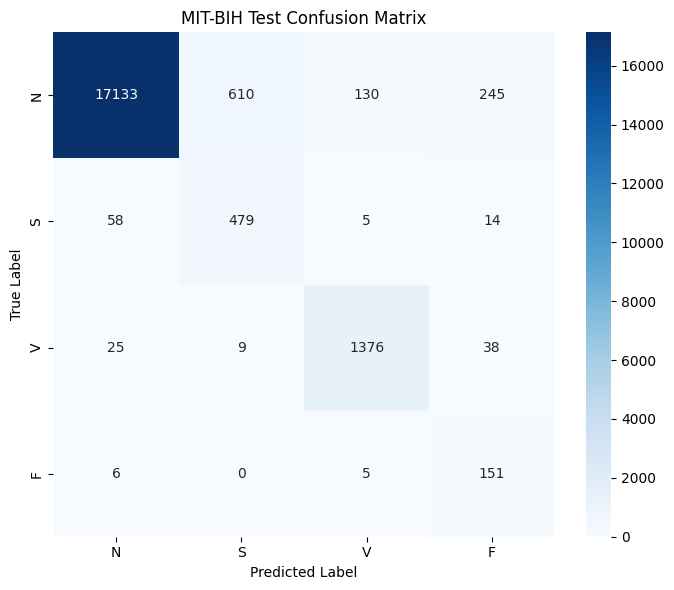

<Figure size 2500x400 with 0 Axes>

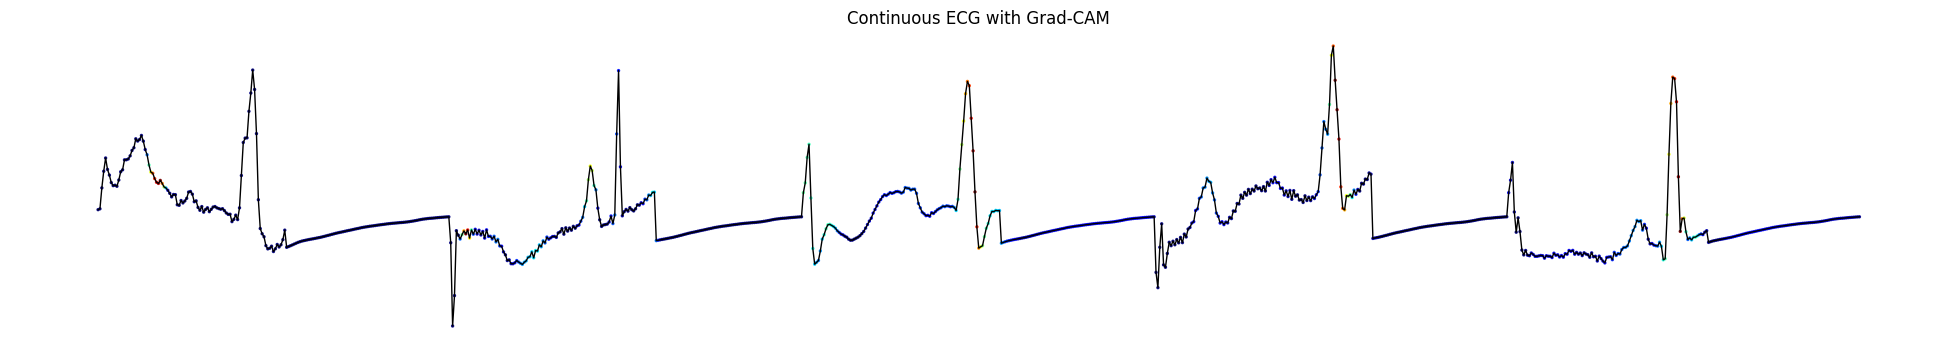

In [39]:
def plot_confusion_matrix(cm, title, save_path=None):
    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar=True
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


OUTPUT_DIR = "./mitbih_ecg_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plot_confusion_matrix(
    test_cm,
    title="MIT-BIH Test Confusion Matrix",
    save_path=os.path.join(OUTPUT_DIR, "test_confusion_matrix.png")
)


import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(25, 4))

all_signals = []
all_heatmaps = []

for sample_index in range(1, 6):

    signal = X_test[sample_index].squeeze()
    heatmap = gradcam_1d(model, X_test[sample_index])

    # normalize heatmap for better visualization
    heatmap = (heatmap - np.min(heatmap)) / (np.max(heatmap) - np.min(heatmap) + 1e-8)

    all_signals.append(signal)
    all_heatmaps.append(heatmap)

full_signal = np.concatenate(all_signals)
full_heatmap = np.concatenate(all_heatmaps)

x = np.arange(len(full_signal))

# ---- WHITE BACKGROUND ----
fig, ax = plt.subplots(figsize=(25, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# ---- ECG SIGNAL (black line) ----
ax.plot(x, full_signal, color="black", linewidth=1)

# ---- CLEAN GRAD-CAM (ONLY ON SIGNAL AREA) ----
#ax.scatter(x, full_signal, c=full_heatmap, cmap="turbo", s=2)
sc = ax.scatter(
    x,
    full_signal,
    c=full_heatmap,
    cmap="jet",
    s=2,              # small dots instead of full background fill
    alpha=0.9
)
# ---- styling ----
ax.set_title("Continuous ECG with Grad-CAM")
ax.axis("off")

plt.show()


In [40]:
!pip install shap lime

In [42]:
import shap

In [43]:
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

In [44]:
test_sample = X_test[:20]

In [46]:
explainer = shap.GradientExplainer(model, background)

In [47]:
shap_values = explainer.shap_values(test_sample)

In [51]:
shap_values_clean = shap_values[:, :, 0, :]   # (20, 187, 4)

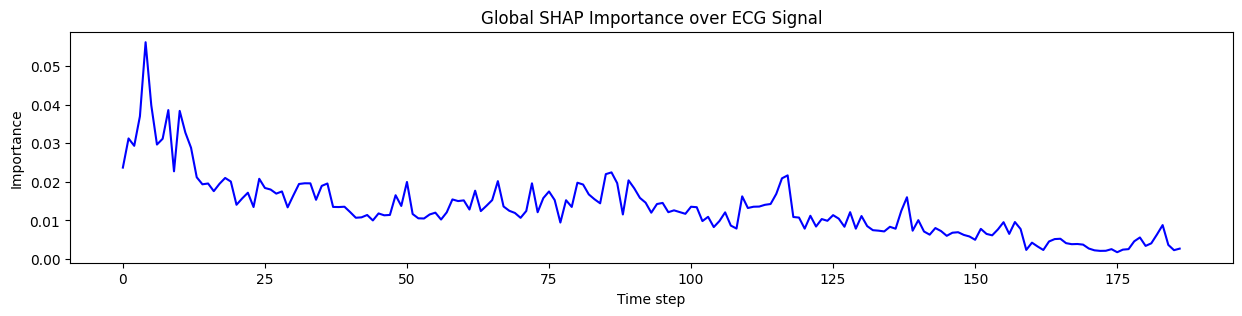

In [54]:
import numpy as np
import matplotlib.pyplot as plt

global_shap = np.mean(np.abs(shap_values_clean), axis=(0, 2))

plt.figure(figsize=(15, 3))
plt.title("Global SHAP Importance over ECG Signal")
plt.plot(global_shap, color="blue")
plt.xlabel("Time step")
plt.ylabel("Importance")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


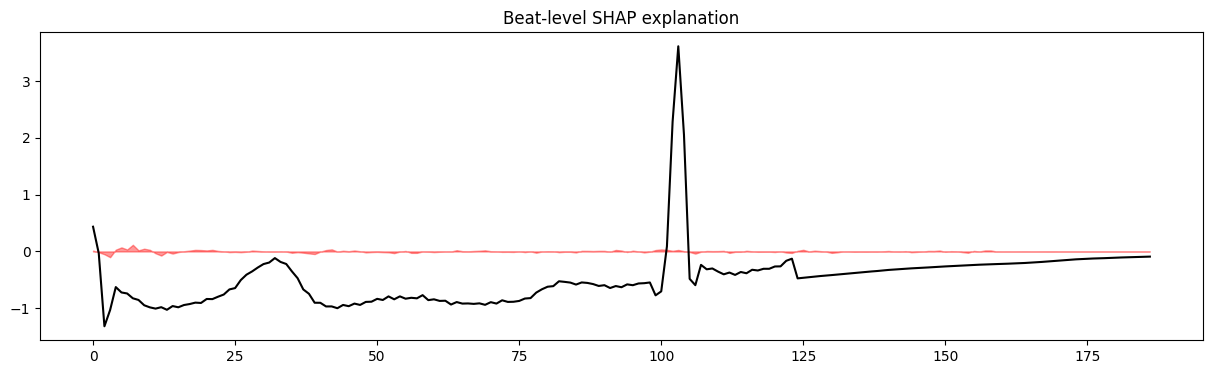

In [58]:
i = 0
pred_class = np.argmax(model.predict(X_test[i:i+1]))

shap_signal = shap_values_clean[i, :, pred_class]

plt.figure(figsize=(15, 4))
plt.plot(X_test[i].squeeze(), color="black")
plt.fill_between(range(187), 0, shap_signal, color="red", alpha=0.4)
plt.title("Beat-level SHAP explanation")
plt.show()

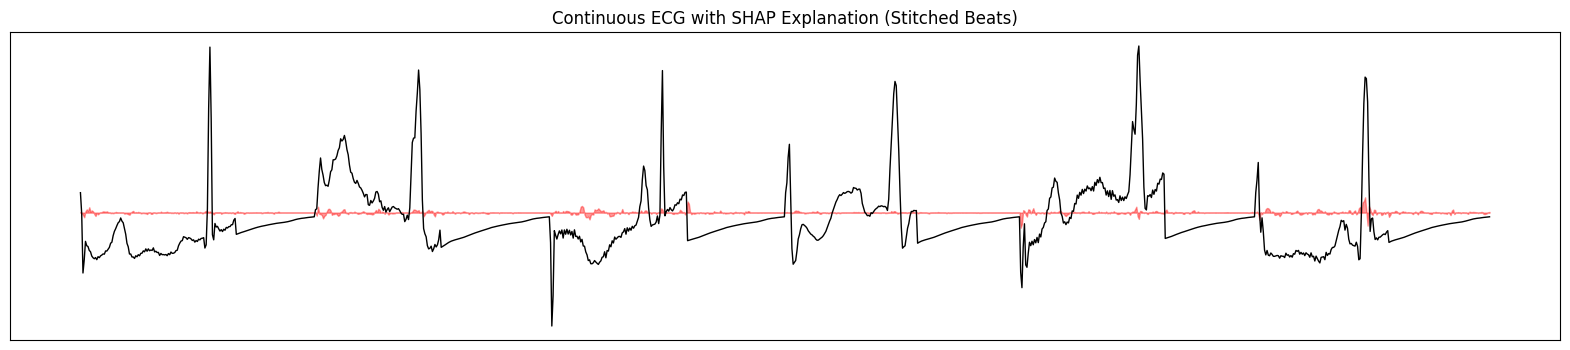

In [64]:
import matplotlib.pyplot as plt
import numpy as np

n_samples = 6  # number of ECG beats to stitch

all_ecg = []
all_shap = []

for i in range(n_samples):

    pred_class = np.argmax(model.predict(X_test[i:i+1], verbose=0))

    ecg = X_test[i].squeeze()
    shap_signal = shap_values_clean[i, :, pred_class]

    all_ecg.append(ecg)
    all_shap.append(shap_signal)

# ---- concatenate into one long signal ----
ecg_continuous = np.concatenate(all_ecg)
shap_continuous = np.concatenate(all_shap)

x = np.arange(len(ecg_continuous))

# ---- single figure ----
plt.figure(figsize=(20, 4))

plt.plot(x, ecg_continuous, color="black", linewidth=1)

plt.fill_between(
    x,
    0,
    shap_continuous,
    color="red",
    alpha=0.4
)

plt.title("Continuous ECG with SHAP Explanation (Stitched Beats)")
plt.xticks([])
plt.yticks([])
plt.show()

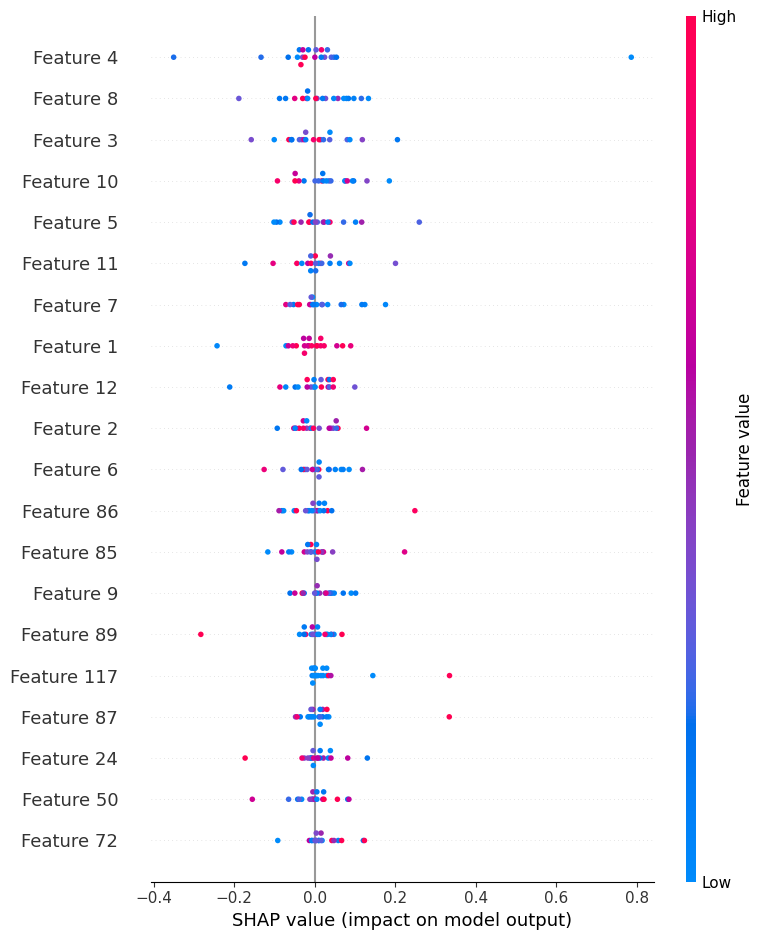

In [50]:
shap.summary_plot(
    shap_class0,
    test_sample.squeeze(),
    show=True
)

In [65]:
!pip install lime

In [66]:
from lime import lime_tabular
import numpy as np

In [67]:
X_train_lime = X_train.reshape(X_train.shape[0], -1)
X_test_lime = X_test.reshape(X_test.shape[0], -1)

In [68]:
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_lime,
    mode="classification",
    class_names=CLASS_NAMES,
    discretize_continuous=False
)

In [69]:
def predict_fn(x):
    x = x.reshape(x.shape[0], 187, 1)
    return model.predict(x)

In [75]:
i = 0

pred_class = np.argmax(model.predict(X_test[i:i+1], verbose=0))

exp = explainer.explain_instance(
    X_test_lime[i],
    predict_fn,
    labels=(pred_class,)
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [76]:
exp.show_in_notebook()

In [74]:
exp.save_to_file("lime_ecg_explanation.html")

In [25]:
OUTPUT_DIR = "./mitbih_ecg_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

model.save(os.path.join(OUTPUT_DIR, "mitbih_ecg_crnn.keras"))
final_metrics_df.to_csv(os.path.join(OUTPUT_DIR, "final_metrics.csv"), index=False)
pd.DataFrame([train_results, val_results, test_results]).to_csv(
    os.path.join(OUTPUT_DIR, "all_split_metrics.csv"),
    index=False
)

pd.DataFrame({
    "true_label": [CLASS_NAMES[i] for i in y_test],
    "pred_label": [CLASS_NAMES[i] for i in y_test_pred]
}).to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

pd.DataFrame(test_cm, index=CLASS_NAMES, columns=CLASS_NAMES).to_csv(
    os.path.join(OUTPUT_DIR, "test_confusion_matrix.csv")
)

print("Saved outputs to:", OUTPUT_DIR)

Saved outputs to: ./mitbih_ecg_outputs
